# Análisis exploratorio de incidencia delictiva en México

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [40]:
df = pd.read_csv('data/datos_delitos.csv', encoding='latin1')

#### Ejercicio 1: Elige 3 estados de la república y grafica una serie de tiempo de la frecuencia abosluta de homicidios dolosos de enero 2015 a julio 2019 en estas tres entidades

In [41]:
estados = ['Guanajuato', 'Jalisco', 'Estado de México']
rango_años = [2015, 2016, 2017, 2018, 2019]

df_hom_dol = df[
    (df['Entidad'].isin(estados)) &
    (df['Año'].isin(rango_años)) &
    (df['Subtipo de delito'] == 'Homicidio doloso')].groupby(['Año', 'Entidad'])[['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio']].sum()

df_hom_dol = df_hom_dol.reset_index()
df_hom_dol

,Año,Entidad,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio
0,2015,Guanajuato,62,64,59,68,66,82,60.0
1,2015,Jalisco,79,68,52,78,73,75,88.0
2,2016,Guanajuato,60,58,72,68,87,91,90.0
3,2016,Jalisco,81,81,91,76,118,76,90.0
4,2017,Guanajuato,88,89,81,88,90,88,87.0
5,2017,Jalisco,102,93,97,105,113,111,101.0
6,2018,Guanajuato,172,156,224,216,237,198,224.0
7,2018,Jalisco,115,134,167,153,166,146,156.0
8,2019,Guanajuato,225,254,248,236,218,202,185.0
9,2019,Jalisco,202,204,166,170,155,177,169.0


#### Ejercicio 2: Contetas las siguientes  preguntas:
1. ¿Cuántos homicidios dolosos hubo en Colima en el 2018?
2. ¿Cuantos robos de vehículo automotor ha habido en el 2019?
3. Obten la suma de homicidos dolosos y feminidios en toda la República Mexicana en cada año.
4. ¿En qué mes y en qué municipio ha ocurrido el mayor número de feminicidios?
5. ¿En qué año y en qué estado ha ocurrido el mayor número de feminicidios?

In [42]:
df_colima = df[
    (df["Entidad"] == "Colima") &
    (df["Año"] == 2018) &
    (df["Subtipo de delito"] == "Homicidio doloso")
]
mes = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]


homicidios_dol_totales = df_colima[mes].sum(axis=1).sum()

print(homicidios_dol_totales)

617.0


In [43]:
df_robo_auto = df[
    (df["Año"] == 2019) &
    (df["Subtipo de delito"] == "Robo de vehículo automotor")
]

mes = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

robos_totales= df_robo_auto[mes].sum().sum()

print(robos_totales)

187661.0


In [44]:
df_delitos = df[df["Subtipo de delito"].isin(["Homicidio doloso", "Feminicidio"])]

mes = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

suma_total = df_delitos.groupby("Año")[mes].sum().sum(axis=1)

print(suma_total)

Año
2015    16532.0
2016    20756.0
2017    25777.0
2018    29995.0
2019    30445.0
2020    29786.0
2021    29263.0
2022    27240.0
2023    26119.0
2024    13255.0
dtype: float64


In [45]:
df_feminicidio = df[df["Subtipo de delito"] == "Feminicidio"]
mes = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]
max_fem_entidad = df_feminicidio.groupby("Entidad")[mes].sum().sum(axis=1).idxmax()
max_fem_mes = df_feminicidio[mes].sum().idxmax()

print(f"El mes con más feminicidios es {max_fem_mes} y la entidad con más feminicidios es {max_fem_entidad}.")


El mes con más feminicidios es Junio y la entidad con más feminicidios es México.


In [46]:

df_max_año_fem = df_feminicidio.groupby("Año")[mes].sum().sum(axis=1).idxmax()
df_max_entidad_fem = df_feminicidio.groupby("Entidad")[mes].sum().sum(axis=1).idxmax()
print(f"El año con más feminicidios es {df_max_año_fem} y la entidad con más feminicidios es {df_max_entidad_fem}.")

El año con más feminicidios es 2021 y la entidad con más feminicidios es México.


#### Ejercicio 3: Haz una gráfica de pastel de tipos de delito. Deberás crear una gráfica para cada año. Utilzia la función subplots de matplotlib

/var/folders/fs/xh1dqrms3wvd57r4g3sz03lm0000gn/T/ipykernel_19631/2229524817.py:29: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


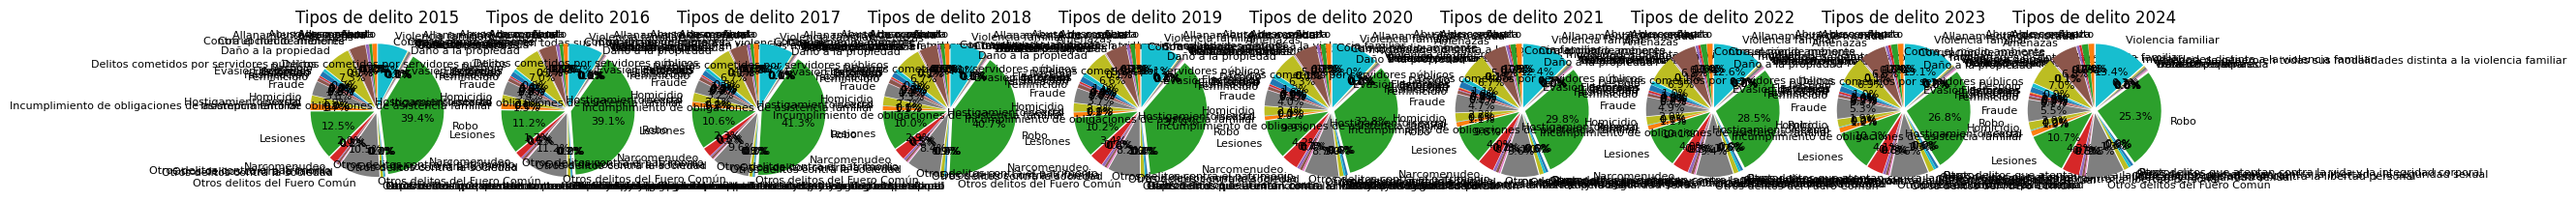

In [47]:
meses = ["Enero","Febrero","Marzo","Abril","Mayo","Junio","Julio","Agosto","Septiembre","Octubre","Noviembre","Diciembre"]

df["Total"] = df[meses].sum(axis=1)

años = sorted(df["Año"].unique())

fig, axes = plt.subplots(1, len(años), figsize=(25,7))

for i, año in enumerate(años):
    
    df_año = df[df["Año"] == año]
    
    tipo_delito = df_año.groupby("Tipo de delito")["Total"].sum()
    
    explode = [0.05] * len(tipo_delito)
    
    axes[i].pie(
        tipo_delito,
        labels=tipo_delito.index,
        autopct='%1.1f%%',
        startangle=90,
        explode=explode,
        labeldistance=1.15,
        textprops={'fontsize':8}
    )
    
    axes[i].set_title(f"Tipos de delito {año}")

plt.tight_layout()
plt.show()

---
#### Calcula la tasa por 100,000 habitantes
##### Tasa por 100,000 habitantes
Mostrar el total de delitos en una entidad no nos sirve de mucho. Es mucho más útil calcular la tasa de incidencia delictiva por cada 100,000 habitantes

$$
tasa = \frac{delitos\space totales}{población} \times 100,000
$$

Esta tasa la podemos anualizar multiplicándola por un factor de 12
$$
tasa\space anualizada = tasa \times 12
$$

Población por entidad federativa según [la encuesta intercensal 2015](https://www.inegi.org.mx/programas/intercensal/2015/)

No tienes que descargar nada. Ya están los datos en la carpeta data

In [48]:
pobs = pd.read_csv('data/poblacion_entidades_2015.csv', encoding='iso-8859-1', sep=";")
pobs = pobs[['Cve_Entidad', 'Entidad', 'Poblacion']]
pobs = pobs.rename(columns={'Cve_Entidad':'clave_entidad', 'Entidad':'entidad', 'Poblacion':'poblacion'})
pobs.head()

,clave_entidad,entidad,poblacion
0,1,Aguascalientes,1312544.0
1,2,Baja California,3315766.0
2,3,Baja California Sur,712029.0
3,4,Campeche,899931.0
4,5,Coahuila de Zaragoza,5217908.0


In [49]:
total_entidad_año = (
    df.groupby(['Año', 'Entidad'])[meses]
    .sum()
    .sum(axis=1)
    .reset_index(name='delitos_totales')
)

total_entidad_año = total_entidad_año.merge(
    pobs,
    left_on='Entidad',
    right_on='entidad',
    how='left'
)
total_entidad_año['tasa_100k'] = (
    total_entidad_año['delitos_totales'] /
    total_entidad_año['poblacion'] * 100_000
)
total_entidad_año['tasa_anualizada'] = total_entidad_año['tasa_100k'] * 12

total_entidad_año.head()

,Año,Entidad,delitos_totales,clave_entidad,entidad,poblacion,tasa_100k,tasa_anualizada
0,2015,Aguascalientes,23212.0,1,Aguascalientes,1312544.0,1768.474047,21221.688568
1,2015,Baja California,119944.0,2,Baja California,3315766.0,3617.384339,43408.612067
2,2015,Baja California Sur,21415.0,3,Baja California Sur,712029.0,3007.602218,36091.226621
3,2015,Campeche,1886.0,4,Campeche,899931.0,209.571623,2514.859473
4,2015,Chiapas,21618.0,7,Chiapas,8918653.0,242.390863,2908.690359
